# Galactic Diffuse Continuum

This tutorial demonstrates how to do a spectral fit of the Galactic diffuse continuum emission using an input GALPROP model in healpix format. 

In [1]:
%%capture
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.io import fits

from astromodels import Model, Parameter, ExtendedSource, Constant
from astromodels.functions import GalPropTemplate_3D

from threeML import JointLikelihood, DataList

from cosipy import COSILike, BinnedData
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.threeml.custom_functions import GalpropHealpixModel
from cosipy.util import fetch_wasabi_file

# Set logging output:
import logging
logging.basicConfig()
logging.getLogger().setLevel(logging.INFO)

%matplotlib inline

### Get the data

In [2]:
# ori file
fetch_wasabi_file('COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits', checksum = '603854cd315ad6e6ff999fa1f55942b6')

In [3]:
# response file
fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5', checksum = '7121f094be50e7bfe9b31e53015b0e85')

In [4]:
# background file
fetch_wasabi_file('COSI-SMEX/DC3/Data/Backgrounds/Ge/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz', checksum = '191a451ee597fd2e4b1cf237fc72e6e2')

In [5]:
# source file
fetch_wasabi_file('COSI-SMEX/DC3/Data/Sources/GalTotal_SA100_F98_3months_unbinned_data_filtered_with_SAAcut.fits.gz', checksum = '9fda5a7b15a90358abc2b886979f9fef')

In [6]:
# precomputed point source response
fetch_wasabi_file('COSI-SMEX/DC3/Data/Responses/extended_source_response/extended_source_response_continuum_merged.h5.gz', unzip = True, checksum = '92ed7e22b1dafce6b57611d5cdb6cf70')

In [7]:
# GALPROP input model
fetch_wasabi_file('COSI-SMEX/cosipy_tutorials/galactic_diffuse_continuum/total_healpix_57_SA100_F98_example.gz', checksum = '82cbeb9a86d86637f19f31c762f379fc')

Input files:

In [8]:
rsp_file = "ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
ori_file = "DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
BG_file = "AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
src_file = "GalTotal_SA100_F98_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
psr_file = "extended_source_response_continuum_merged.h5"
galprop_model_file = "total_healpix_57_SA100_F98_example.gz"

### Make the dataset and bin
This step only needs to be run once. Afterwards, the files can be loaded directly using the cell below. 

In [9]:
# Make combined dataset:
analysis = BinnedData("galdiff.yaml")
input_files = [BG_file,src_file]
analysis.combine_unbinned_data(input_files, output_name="combined_data")

# Bin galdiff:
galdiff = BinnedData("galdiff.yaml")
galdiff.get_binned_data(unbinned_data=src_file, output_name="galdiff_binned_data")

# Bin background:
bg_tot = BinnedData("galdiff.yaml")
bg_tot.get_binned_data(unbinned_data=BG_file, output_name="albedo_photons_binned_data")

# Bin combined data:
data_combined = BinnedData("galdiff.yaml")
data_combined.get_binned_data(unbinned_data="combined_data.fits.gz", output_name="combined_binned_data")

Load binned files:

In [10]:
galdiff = BinnedData("galdiff.yaml")
galdiff.load_binned_data_from_hdf5(binned_data="galdiff_binned_data.hdf5")

# Load background:
bg_tot = BinnedData("galdiff.yaml")
bg_tot.load_binned_data_from_hdf5(binned_data="albedo_photons_binned_data.hdf5")

# Load combined data:
data_combined = BinnedData("galdiff.yaml")
data_combined.load_binned_data_from_hdf5(binned_data="combined_binned_data.hdf5")

## Define GALPROP model
Below is how to define the custom GALPROP model. We will save the model to a yaml file so that it can be directly uploaded in the future (as shown at the bottom). 

In [11]:
# defining the model:
galprop_model = GalpropHealpixModel()
galprop_model.load_file(galprop_model_file)

# The spectrum is defined in the data cube, 
# and so we use a dummy model for defining an extended source in astromodels. 
# NB: This has no impact on the results - just make sure the parameter is fixed!
spectrum = Constant()
spectrum.k.value = 0.0
spectrum.k.free = False

src = ExtendedSource("galprop_source", spatial_shape=galprop_model, spectral_shape=spectrum)
model = Model(src)
model.save("galprop_model.yaml", overwrite=True)

# uncomment below to load saved model:
#model = load_model('galprop_model.yaml')

## Setup and perform fit
Set background parameter, which is used to fit the amplitude of the background:

In [12]:
bkg_par = Parameter("background_cosi",                                        # background parameter
                    1,                                                        # initial value of parameter
                    min_value=0,                                              # minimum value of parameter
                    max_value=5,                                              # maximum value of parameter
                    delta=0.05,                                               # initial step used by fitting engine
                    desc="Background parameter for cosi")

Specify orientation:

In [13]:
ori = SpacecraftFile.open(ori_file)

Instantiate the COSI 3ML plugin

In [14]:
%%time
cosi = COSILike("cosi",                                                       # COSI 3ML plugin
    dr = rsp_file,                                                            # detector response
    data = data_combined.binned_data.project('Em', 'Phi', 'PsiChi'),          # data (source+background)
    bkg = bg_tot.binned_data.project('Em', 'Phi', 'PsiChi'),                  # background model
    sc_orientation = ori,                                                     # spacecraft orientation
    nuisance_param = bkg_par,                                                 # background parameter                        
    precomputed_psr_file = psr_file)                                          # precomputed extended source response 

CPU times: user 71.1 ms, sys: 4.83 s, total: 4.9 s
Wall time: 4.92 s


Perform fit:

In [15]:
%%time
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose = False)
like.fit();

15:00:20 INFO      set the minimizer to minuit                                              ]8;id=959197;file:///project/cassini/cosi/threeML_git/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=80216;file:///project/cassini/cosi/threeML_git/threeML/classicMLE/joint_likelihood.py#994\994]8;;\

15:00:40 WARNING   get_number_of_data_points not implemented, values for statistical        ]8;id=271288;file:///project/cassini/cosi/threeML_git/threeML/plugin_prototype.py\plugin_prototype.py]8;;\:]8;id=35756;file:///project/cassini/cosi/threeML_git/threeML/plugin_prototype.py#119\119]8;;\
                  measurements such as AIC or BIC are unreliable                                                   

Best fit values:

,result,unit
parameter,,
galprop_source.GalpropHealpixModel.K,(7.721 +/- 0.008) x 10^-1,
background_cosi,1.00771 +/- 0.00029,


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1.716557e+08
total,-1.716557e+08


Values of statistical measures:

,statistical measures
AIC,-3.433114e+08
BIC,-3.433114e+08


CPU times: user 2min 12s, sys: 63.5 ms, total: 2min 12s
Wall time: 19.3 s


The best-fit normalizations are: <br>
galprop map: 0.7721 +/- 0.0008 <br>
background: 1.00771 +/- 0.00029 <br>
Thus, we recover the background to within <1%,although the galprop normalization is lower than the input by ~23%. The discrepancy is likely due to the coarse energy binning. The predicted counts agree to within ~6%. Below we plot some of the results, and compare to the inputs. 

## Make plots

Compare best-fit to injected source:

galdiff expected counts:
[7.75334204e+05 1.89566414e+06 1.76323631e+06 1.10662650e+06
 6.56071246e+05 3.87738649e+05 2.35773985e+05 9.77339482e+04
 2.13603980e+04 1.03920658e+03]


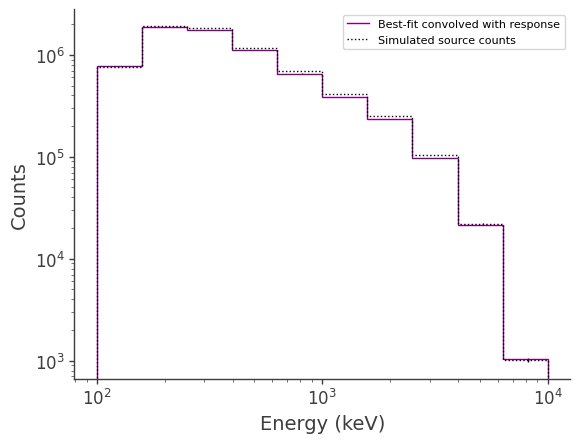

In [16]:
# Get expected counts from likelihood scan (i.e. best-fit convolved with response):
total_expectation = cosi._expected_counts['galprop_source']
total_expectation_em = total_expectation.project('Em').todense().contents
galdiff_em = galdiff.binned_data.project('Em').todense().contents

print("galdiff expected counts:")
print(total_expectation_em)

fig,ax = plt.subplots()

binned_energy_edges = galdiff.binned_data.axes['Em'].edges.value
binned_energy = galdiff.binned_data.axes['Em'].centers.value

ax.stairs(total_expectation_em, binned_energy_edges, color='purple', label = "Best-fit convolved with response")
ax.errorbar(binned_energy, total_expectation_em, yerr=np.sqrt(total_expectation_em), color='purple', linewidth=0, elinewidth=1)
ax.stairs(galdiff_em, binned_energy_edges, color = 'black', ls = ":", label = "Simulated source counts")
ax.errorbar(binned_energy, galdiff_em, yerr=np.sqrt(galdiff_em), color='black', linewidth=0, elinewidth=1)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")
plt.yscale('log')
plt.xscale('log')
ax.legend()

plt.savefig("injected_model_comparison.pdf")

percent difference: 

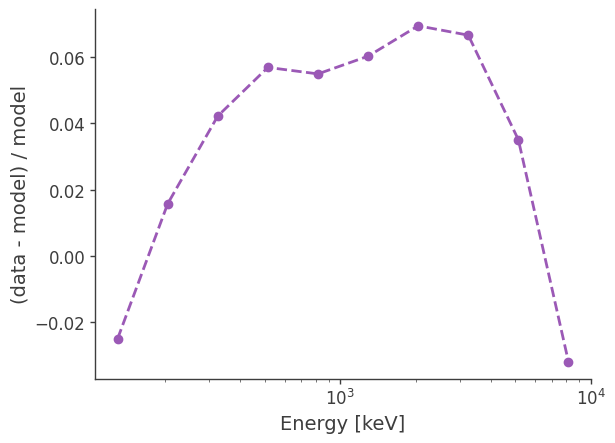

In [17]:
diff = (galdiff_em - total_expectation_em)/total_expectation_em

plt.semilogx(binned_energy,diff,ls="--",marker="o")
plt.xlabel("Energy [keV]")
plt.ylabel("(data - model) / model")

plt.savefig("percent_diff.pdf")

Compare best-fit to injected for total counts:

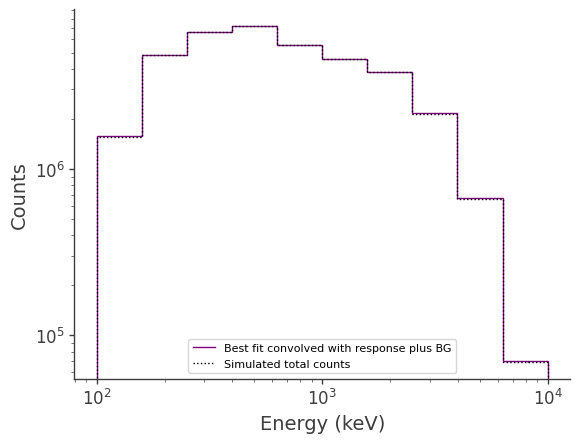

In [18]:
fit_em = total_expectation_em + bkg_par.value * bg_tot.binned_data.project('Em').todense().contents
inj_em = data_combined.binned_data.project('Em').todense().contents

fig,ax = plt.subplots()

ax.stairs(fit_em, binned_energy_edges, color='purple', label = "Best fit convolved with response plus BG")
ax.errorbar(binned_energy, fit_em, yerr=np.sqrt(fit_em), color='purple', linewidth=0, elinewidth=1)
ax.stairs(inj_em, binned_energy_edges, color = 'black', ls = ":", label = "Simulated total counts")
ax.errorbar(binned_energy, inj_em, yerr=np.sqrt(inj_em), color='black', linewidth=0, elinewidth=1)

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()
plt.yscale('log')
plt.xscale('log')

plt.savefig("injected_total_comparison.pdf")

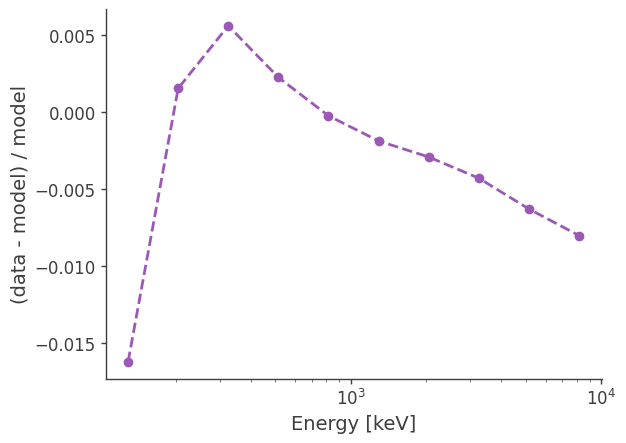

In [19]:
diff = (inj_em - fit_em)/fit_em

plt.semilogx(binned_energy,diff,ls="--",marker="o")
plt.xlabel("Energy [keV]")
plt.ylabel("(data - model) / model")

plt.savefig("percent_diff.pdf")

Plot average intensity (averaged over full sky):

intensity error:
[6.29596129e-07 6.65644045e-07 6.94274489e-07 7.33096855e-07
 7.74890478e-07 8.45853961e-07 9.19414834e-07 1.02855586e-06
 1.13351549e-06 1.28234154e-06]


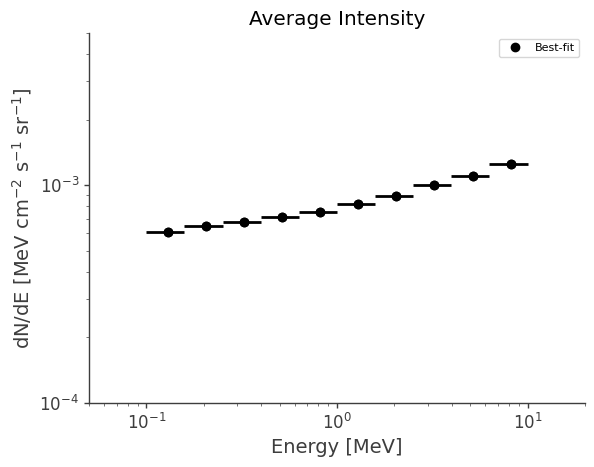

In [20]:
results = like.results
mle_data = results.get_data_frame()
K    = mle_data["value"]["galprop_source.GalpropHealpixModel.K"]
Kerr = mle_data["error"]["galprop_source.GalpropHealpixModel.K"]

# We will pass the response nside in order to use the same spatial sampling as the fit:
with FullDetectorResponse.open(rsp_file) as response:
    nside = response.nside

# We will also use the same energy values as was used in the fit:
binned_energy_edges = galdiff.binned_data.axes['Em'].edges.to(u.MeV).value
binned_energy = galdiff.binned_data.axes['Em'].centers.to(u.MeV).value
energy_err = 0.5*np.diff(binned_energy_edges)

# Below we will pass avg_int=True in order to get the average intensity. Otherwise, the function returns the total intensity by default.
intensity = results.optimized_model["galprop_source"].spatial_shape.get_total_spatial_integral(binned_energy, avg_int=True, nside=nside)
intensity = intensity.value

yerr = (Kerr/K)*intensity
yerr *= binned_energy**2
print("intensity error:")
print(yerr)

intensity *= binned_energy**2

fig,ax = plt.subplots()

ax.loglog(binned_energy, intensity, ls="", marker="o", color="black", label = "Best-fit")
ax.errorbar(binned_energy, intensity, xerr=energy_err, yerr=yerr, ls="", marker="o", color="black", label = "_nolabel_")

# Plot model specturm with galpy:
# This is optional and requires galpy package:
# https://github.com/ckarwin/galpy
#from galpy import GalMapsHeal
#instance = GalMapsHeal()
#instance.read_healpix_file("GALPROP_DC3/total_healpix_57_SA100_F98_example.gz")
#instance.make_spectrum()
#gal_energy = instance.energy
#gal_spec = instance.spectra_list
#ax.loglog(gal_energy, gal_spec, ls="-", marker="", color="red", label = "GALPROP model")

plt.ylabel(r"dN/dE [$\mathrm{MeV \ cm^{-2} \ s^{-1} \ sr^{-1}}$]")
plt.xlabel("Energy [MeV]")
plt.title("Average Intensity")
ax.legend()
plt.xlim(5e-2,20)
plt.ylim(1e-4,5e-3)

plt.savefig("intensity.pdf")

Below we plot the best-fit spectrum just for demonstration. Again, this is just a dummy model since the spectrum is contained in the 3D data cube. This has no impact on the fit.    

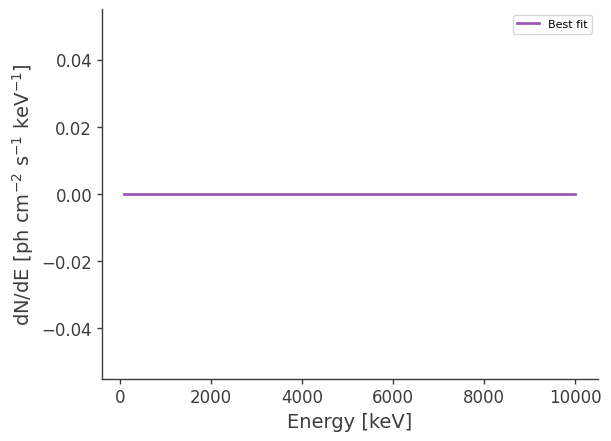

In [21]:
energy = np.linspace(100.,10000.,201)*u.keV
flux = results.optimized_model["galprop_source"].spectrum.main.shape(energy)

fig,ax = plt.subplots()

ax.plot(energy, flux, label = "Best fit")

plt.ylabel(r"dN/dE [$\mathrm{ph \ cm^{-2} \ s^{-1} \ keV^{-1}}$]", fontsize=14)
plt.xlabel("Energy [keV]", fontsize=14)
ax.legend()

plt.savefig("best_fit_model.pdf")